In [27]:
#Import required libraries and load the dataset
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
# Load the combined ESG and financial dataset (15 companies x 4 years)
df = pd.read_csv('esg_financial_panel.csv')
df.head()

,Company,Ticker,Year,ESG_Score_Letter,ESG_Score_Numeric,Env_Pillar_Letter,Env_Pillar_Numeric,Social_Pillar_Letter,Social_Pillar_Numeric,Gov_Pillar_Letter,Gov_Pillar_Numeric,ROE_PBT,ROCE_PBT,ROA_PBT,ROE_NI,ROCE_NI,ROA_NI,Profit_Margin,Gross_Margin,EBITDA_Margin,EBIT_Margin,CF_Revenue,EV_EBITDA,MCap_CFO,Net_Assets_Turnover
0,ASOS plc,ASC,2021,B-,7,B-,7,C,5,A-,10,17.13,10.09,6.14,12.42,7.51,4.45,4.53,48.89,8.37,4.90,6.75,12.25,18.03,2.07
1,ASOS plc,ASC,2022,B-,7,B-,7,C+,6,B+,9,-3.14,-0.46,-1.06,-3.04,-0.40,-1.03,-0.81,47.92,3.36,-0.93,3.51,9.28,NaN,2.01
2,ASOS plc,ASC,2023,B-,7,C+,6,C+,6,A,11,-34.23,-12.75,-11.30,-25.74,-8.89,-8.50,-8.35,46.85,-1.29,-7.00,-0.57,NaN,32.70,1.86
3,ASOS plc,ASC,2024,B,8,C+,6,B-,7,A-,10,-72.76,-20.54,-16.70,-64.97,-17.94,-14.91,-13.04,49.92,-1.47,-11.34,-1.78,NaN,1.90,1.87
4,Currys plc,CURY,2021,B-,7,B+,9,C+,6,B,8,1.68,3.76,0.58,0.50,3.10,0.17,0.39,21.22,6.46,2.24,4.34,4.16,1.93,2.43


In [28]:
# View the entire dataset
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df

,Company,Ticker,Year,ESG_Score_Letter,ESG_Score_Numeric,Env_Pillar_Letter,Env_Pillar_Numeric,Social_Pillar_Letter,Social_Pillar_Numeric,Gov_Pillar_Letter,Gov_Pillar_Numeric,ROE_PBT,ROCE_PBT,ROA_PBT,ROE_NI,ROCE_NI,ROA_NI,Profit_Margin,Gross_Margin,EBITDA_Margin,EBIT_Margin,CF_Revenue,EV_EBITDA,MCap_CFO,Net_Assets_Turnover
0,ASOS plc,ASC,2021,B-,7,B-,7,C,5,A-,10,17.13,10.09,6.14,12.42,7.51,4.45,4.53,48.89,8.37,4.90,6.75,12.25,18.03,2.07
1,ASOS plc,ASC,2022,B-,7,B-,7,C+,6,B+,9,-3.14,-0.46,-1.06,-3.04,-0.40,-1.03,-0.81,47.92,3.36,-0.93,3.51,9.28,NaN,2.01
2,ASOS plc,ASC,2023,B-,7,C+,6,C+,6,A,11,-34.23,-12.75,-11.30,-25.74,-8.89,-8.50,-8.35,46.85,-1.29,-7.00,-0.57,NaN,32.70,1.86
3,ASOS plc,ASC,2024,B,8,C+,6,B-,7,A-,10,-72.76,-20.54,-16.70,-64.97,-17.94,-14.91,-13.04,49.92,-1.47,-11.34,-1.78,NaN,1.90,1.87
4,Currys plc,CURY,2021,B-,7,B+,9,C+,6,B,8,1.68,3.76,0.58,0.50,3.10,0.17,0.39,21.22,6.46,2.24,4.34,4.16,1.93,2.43
5,Currys plc,CURY,2022,B+,9,B+,9,B-,7,B+,9,5.04,5.32,1.82,2.84,4.01,1.03,1.24,21.60,6.81,2.84,4.67,3.30,2.47,2.41
6,Currys plc,CURY,2023,A-,10,B+,9,A-,10,A,11,-23.78,-10.11,-7.69,-25.42,-11.01,-8.22,-4.73,26.49,5.64,-3.07,3.65,3.69,2.39,2.75
7,Currys plc,CURY,2024,A-,10,B,8,A-,10,A,11,1.45,3.97,0.57,7.96,8.21,3.11,0.33,27.17,5.53,1.94,5.41,3.21,1.92,2.85
8,Dunelm Group plc,DNLM,2021,B+,9,B+,9,B,8,B+,9,56.12,30.92,20.58,45.84,25.47,16.81,11.81,57.43,18.50,12.63,15.52,12.30,15.61,2.52
9,Dunelm Group plc,DNLM,2022,B,8,A-,10,B,8,B,8,119.35,47.39,28.84,96.02,38.39,23.20,13.46,56.18,18.78,13.79,15.82,5.71,6.65,3.42


In [29]:
# Check the shape and structure of the dataset
print(f"Shape: {df.shape}")
print(f"Companies: {df['Company'].nunique()}")
print(f"Years covered: {sorted(df['Year'].unique())}")
df.info()

Shape: (60, 25)
Companies: 15
Years covered: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Company                60 non-null     object 
 1   Ticker                 60 non-null     object 
 2   Year                   60 non-null     int64  
 3   ESG_Score_Letter       60 non-null     object 
 4   ESG_Score_Numeric      60 non-null     int64  
 5   Env_Pillar_Letter      60 non-null     object 
 6   Env_Pillar_Numeric     60 non-null     int64  
 7   Social_Pillar_Letter   60 non-null     object 
 8   Social_Pillar_Numeric  60 non-null     int64  
 9   Gov_Pillar_Letter      60 non-null     object 
 10  Gov_Pillar_Numeric     60 non-null     int64  
 11  ROE_PBT                60 non-null     float64
 12  ROCE_PBT               60 non-null     float64
 13  RO

In [30]:
#Print the list of all column names in the dataset
print(df.columns.tolist())

['Company', 'Ticker', 'Year', 'ESG_Score_Letter', 'ESG_Score_Numeric', 'Env_Pillar_Letter', 'Env_Pillar_Numeric', 'Social_Pillar_Letter', 'Social_Pillar_Numeric', 'Gov_Pillar_Letter', 'Gov_Pillar_Numeric', 'ROE_PBT', 'ROCE_PBT', 'ROA_PBT', 'ROE_NI', 'ROCE_NI', 'ROA_NI', 'Profit_Margin', 'Gross_Margin', 'EBITDA_Margin', 'EBIT_Margin', 'CF_Revenue', 'EV_EBITDA', 'MCap_CFO', 'Net_Assets_Turnover']


In [31]:
# Check for missing values in the dataset
missing = df.isna().sum()
print(missing[missing > 0])


Gross_Margin    2
EV_EBITDA       5
MCap_CFO        3
dtype: int64


In [32]:
# Calculate descriptive statistics (mean, std, min, max, range)
desc_vars = ['ESG_Score_Numeric', 'Env_Pillar_Numeric', 'Social_Pillar_Numeric',
             'Gov_Pillar_Numeric', 'ROA_NI', 'ROE_NI', 'ROA_PBT', 'ROE_PBT',
             'Net_Assets_Turnover']
desc_stats = df[desc_vars].describe().T
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats.round(2)

,count,mean,std,min,25%,50%,75%,max,range
ESG_Score_Numeric,60.0,8.53,1.42,5.00,8.00,9.00,10.00,11.00,6.00
Env_Pillar_Numeric,60.0,8.58,1.45,4.00,8.00,9.00,10.00,12.00,8.00
Social_Pillar_Numeric,60.0,8.25,2.14,3.00,6.00,9.00,10.00,12.00,9.00
Gov_Pillar_Numeric,60.0,8.82,1.61,3.00,8.00,9.00,10.00,11.00,8.00
ROA_NI,60.0,4.45,7.81,-14.91,0.97,4.17,6.88,23.20,38.11
ROE_NI,60.0,14.21,30.84,-64.97,2.85,10.34,20.98,110.47,175.44
ROA_PBT,60.0,5.75,9.56,-16.70,1.22,5.62,8.59,30.12,46.82
ROE_PBT,60.0,18.23,38.35,-72.76,3.92,13.80,28.05,148.95,221.71
Net_Assets_Turnover,60.0,1.81,0.69,0.64,1.43,1.74,2.12,4.08,3.44


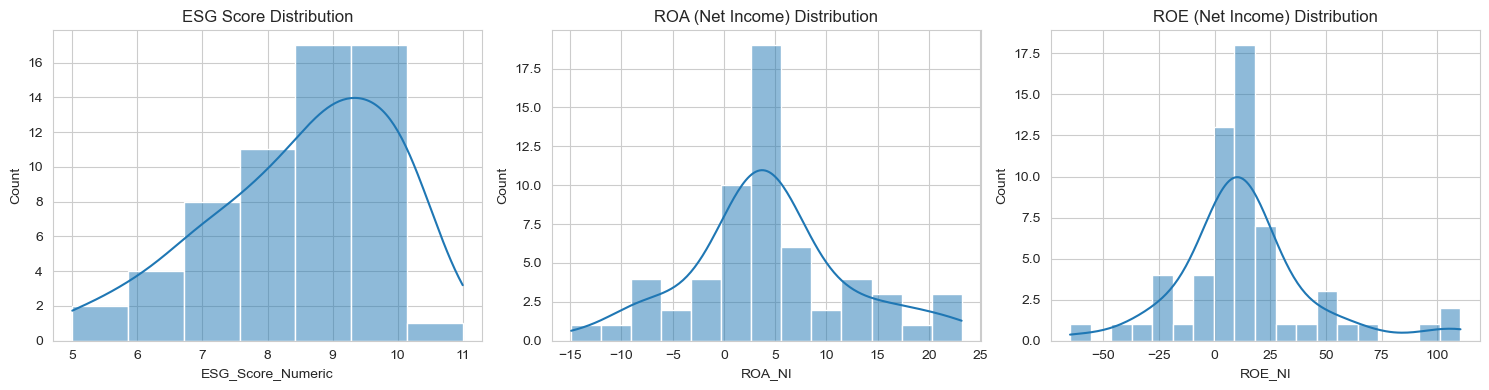

In [33]:
# Plot distributions of key variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['ESG_Score_Numeric'], kde=True, ax=axes[0])
axes[0].set_title('ESG Score Distribution')
sns.histplot(df['ROA_NI'], kde=True, ax=axes[1])
axes[1].set_title('ROA (Net Income) Distribution')
sns.histplot(df['ROE_NI'], kde=True, ax=axes[2])
axes[2].set_title('ROE (Net Income) Distribution')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()



In [34]:
# Run normality test to check data distribution
for var in ['ESG_Score_Numeric', 'ROA_NI', 'ROE_NI']:
    stat, p = stats.shapiro(df[var].dropna())
    print(f"{var}: Shapiro-Wilk p = {p:.4f} {'(non-normal)' if p < 0.05 else '(normal)'}")

ESG_Score_Numeric: Shapiro-Wilk p = 0.0002 (non-normal)
ROA_NI: Shapiro-Wilk p = 0.0374 (non-normal)
ROE_NI: Shapiro-Wilk p = 0.0000 (non-normal)


In [35]:
# Run correlation analysis (Pearson and Spearman)
correlation_results = []
for dv in ['ROA_NI', 'ROE_NI', 'ROA_PBT', 'ROE_PBT']:
    sub = df[['ESG_Score_Numeric', dv]].dropna()
    pear_r, pear_p = stats.pearsonr(sub['ESG_Score_Numeric'], sub[dv])
    spear_r, spear_p = stats.spearmanr(sub['ESG_Score_Numeric'], sub[dv])
    correlation_results.append({
        'Variable': dv, 'N': len(sub),
        'Pearson r': round(pear_r, 3), 'Pearson p': round(pear_p, 4),
        'Spearman r': round(spear_r, 3), 'Spearman p': round(spear_p, 4)
    })
corr_df = pd.DataFrame(correlation_results)
corr_df

,Variable,N,Pearson r,Pearson p,Spearman r,Spearman p
0,ROA_NI,60,-0.005,0.9690,-0.110,0.4048
1,ROE_NI,60,-0.026,0.8437,-0.097,0.4589
2,ROA_PBT,60,-0.067,0.6134,-0.192,0.1413
3,ROE_PBT,60,-0.079,0.5483,-0.164,0.2119


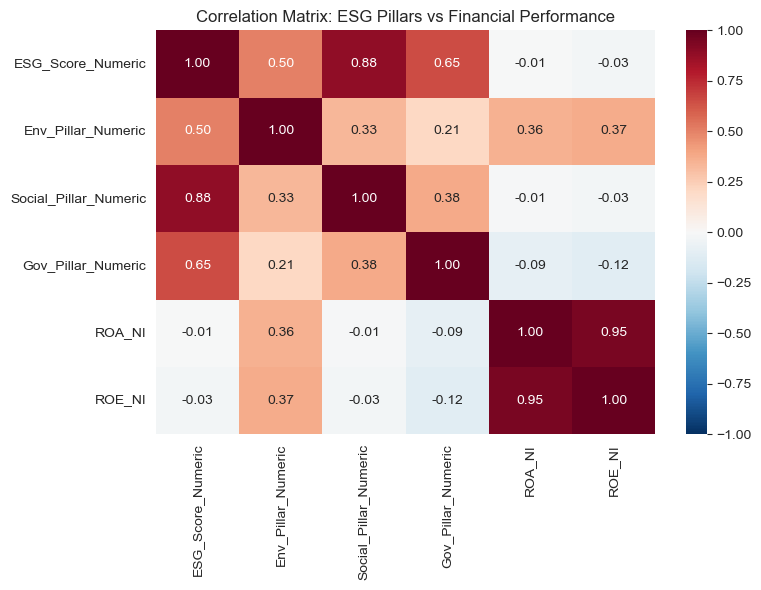

In [36]:
# Plot correlation heatmap
corr_vars = ['ESG_Score_Numeric', 'Env_Pillar_Numeric', 'Social_Pillar_Numeric',
             'Gov_Pillar_Numeric', 'ROA_NI', 'ROE_NI']
corr_matrix = df[corr_vars].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix: ESG Pillars vs Financial Performance')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [37]:
# Run regression: ESG Score vs ROA
model_h1 = smf.ols('ROA_NI ~ ESG_Score_Numeric', data=df).fit()
print(model_h1.summary())

                            OLS Regression Results                            
Dep. Variable:                 ROA_NI   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                  0.001526
Date:                Fri, 21 Aug 2026   Prob (F-statistic):              0.969
Time:                        13:57:24   Log-Likelihood:                -207.94
No. Observations:                  60   AIC:                             419.9
Df Residuals:                      58   BIC:                             424.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.6905      6.24

In [38]:
# Run regression: ESG Score vs ROE
model_h2 = smf.ols('ROE_NI ~ ESG_Score_Numeric', data=df).fit()
print(model_h2.summary())

                            OLS Regression Results                            
Dep. Variable:                 ROE_NI   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                   0.03921
Date:                Fri, 21 Aug 2026   Prob (F-statistic):              0.844
Time:                        13:57:24   Log-Likelihood:                -290.34
No. Observations:                  60   AIC:                             584.7
Df Residuals:                      58   BIC:                             588.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            19.0235     24.65

In [39]:
# Run regression: ESG Score vs ROA, with Net Assets Turnover as control
model_h1_control = smf.ols('ROA_NI ~ ESG_Score_Numeric + Net_Assets_Turnover', data=df).fit()
print(model_h1_control.summary())

                            OLS Regression Results                            
Dep. Variable:                 ROA_NI   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.185
Method:                 Least Squares   F-statistic:                     7.675
Date:                Fri, 21 Aug 2026   Prob (F-statistic):            0.00112
Time:                        13:57:24   Log-Likelihood:                -200.79
No. Observations:                  60   AIC:                             407.6
Df Residuals:                      57   BIC:                             413.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -3.9549    

In [40]:
# Run regression: ESG Score vs ROE, with Net Assets Turnover as control
model_h2_control = smf.ols('ROE_NI ~ ESG_Score_Numeric + Net_Assets_Turnover', data=df).fit()
print(model_h2_control.summary())

                            OLS Regression Results                            
Dep. Variable:                 ROE_NI   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     12.93
Date:                Fri, 21 Aug 2026   Prob (F-statistic):           2.35e-05
Time:                        13:57:24   Log-Likelihood:                -279.14
No. Observations:                  60   AIC:                             564.3
Df Residuals:                      57   BIC:                             570.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             -22.3424    

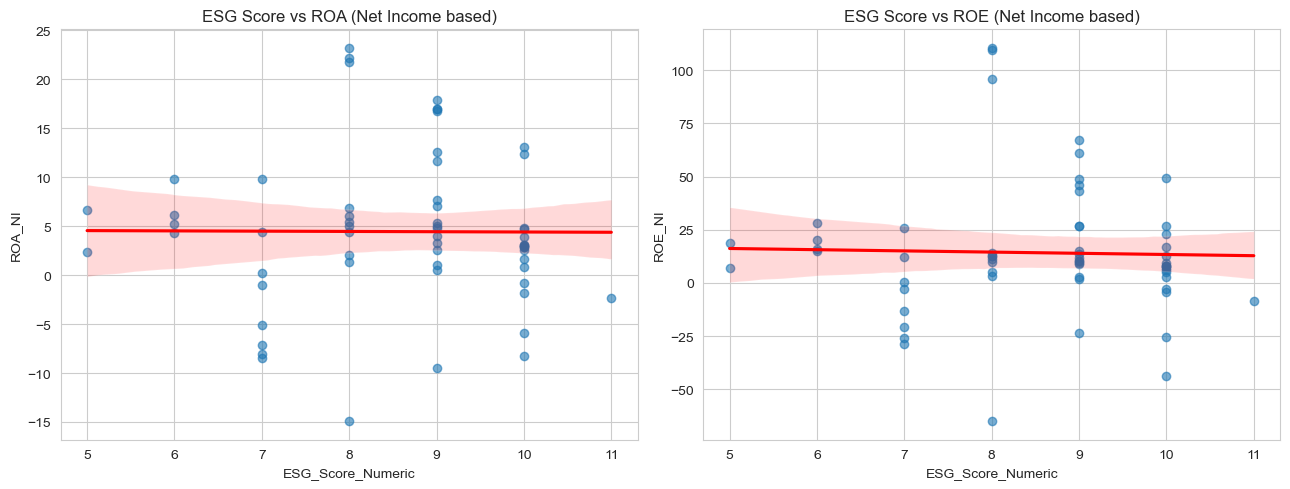

In [41]:
# Plot regression scatter plots with line of best fit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(data=df, x='ESG_Score_Numeric', y='ROA_NI', ax=axes[0],
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[0].set_title('ESG Score vs ROA (Net Income based)')
sns.regplot(data=df, x='ESG_Score_Numeric', y='ROE_NI', ax=axes[1],
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
axes[1].set_title('ESG Score vs ROE (Net Income based)')
plt.tight_layout()
plt.savefig('regression_scatterplots.png', dpi=150)
plt.show()

In [42]:
# Split companies into High and Low ESG groups using median score
median_esg = df['ESG_Score_Numeric'].median()
df['ESG_Group'] = np.where(df['ESG_Score_Numeric'] >= median_esg, 'High', 'Low')

print(f"Median ESG score (split point): {median_esg}")
print(df['ESG_Group'].value_counts())

Median ESG score (split point): 9.0
ESG_Group
High    35
Low     25
Name: count, dtype: int64


In [43]:
# Compare average financial performance between High and Low ESG groups
group_summary = df.groupby('ESG_Group')[['ROA_NI', 'ROE_NI']].agg(['mean', 'std', 'count']).round(2)
group_summary

ROA_NI             ROE_NI             
            mean   std count   mean    std count
ESG_Group                                       
High        4.70  6.77    35  13.72  23.13    35
Low         4.11  9.20    25  14.89  39.74    25

In [44]:
# Run t-tests to compare High vs Low ESG groups
for var in ['ROA_NI', 'ROE_NI']:
    high = df[df['ESG_Group'] == 'High'][var].dropna()
    low = df[df['ESG_Group'] == 'Low'][var].dropna()
    t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)
    print(f"\n{var}:")
    print(f"  High ESG group: mean = {high.mean():.2f}, n = {len(high)}")
    print(f"  Low ESG group:  mean = {low.mean():.2f}, n = {len(low)}")
    print(f"  Welch's t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
    print(f"  {'Significant at 5% level' if p_val < 0.05 else 'Not statistically significant at 5% level'}")


ROA_NI:
  High ESG group: mean = 4.70, n = 35
  Low ESG group:  mean = 4.11, n = 25
  Welch's t-test: t = 0.272, p = 0.7872
  Not statistically significant at 5% level

ROE_NI:
  High ESG group: mean = 13.72, n = 35
  Low ESG group:  mean = 14.89, n = 25
  Welch's t-test: t = -0.131, p = 0.8961
  Not statistically significant at 5% level


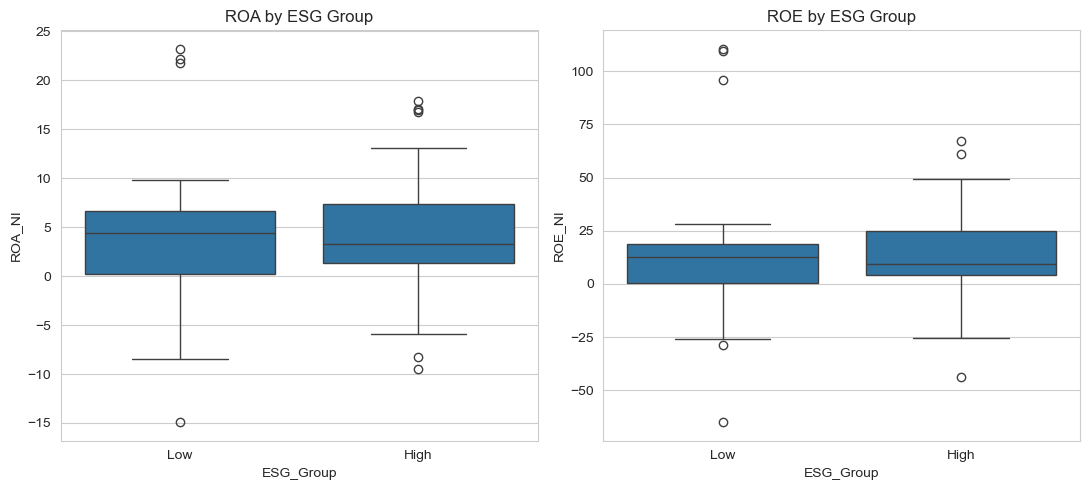

In [45]:
# Plot boxplots comparing High and Low ESG groups
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(data=df, x='ESG_Group', y='ROA_NI', ax=axes[0], order=['Low','High'])
axes[0].set_title('ROA by ESG Group')
sns.boxplot(data=df, x='ESG_Group', y='ROE_NI', ax=axes[1], order=['Low','High'])
axes[1].set_title('ROE by ESG Group')
plt.tight_layout()
plt.savefig('group_comparison_boxplots.png', dpi=150)
plt.show()

In [47]:
# Save the final dataset with ESG_Group column added
df.to_csv('esg_financial_panel_final.csv', index=False)
print("Done. Results saved.")

Done. Results saved.
